### 1. Extracting and Loading the CIFAR-10 Dataset

In [3]:
import tarfile
import os
import pickle
import numpy as np

# Define the path to the compressed dataset
DATA_PATH = '/content/cifar-10-python.tar.gz'
EXTRACT_DIR = '/content/cifar-10-batches-py'

# Create a directory for extraction if it doesn't exist
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

# Extract the tar.gz file
print(f"Extracting data from {DATA_PATH} to {EXTRACT_DIR}...")
with tarfile.open(DATA_PATH, 'r:gz') as tar:
    tar.extractall(path='/content/')
print("Extraction complete.")


Extracting data from /content/cifar-10-python.tar.gz to /content/cifar-10-batches-py...


/tmp/ipykernel_897/653841937.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content/')


Extraction complete.


In [5]:
def load_cifar_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']
    labels = np.array(batch[b'labels']) # Convert labels list to numpy array
    return data, labels

def load_cifar10_data(root_dir):
    xs = []
    ys = []
    for b in range(1, 6):
        f = os.path.join(root_dir, 'data_batch_%d' % (b,))
        X, Y = load_cifar_batch(f)
        xs.append(X)
        ys.append(Y)
    Xtr = np.concatenate(xs)
    Ytr = np.concatenate(ys)
    Xte, Yte = load_cifar_batch(os.path.join(root_dir, 'test_batch'))
    return Xtr, Ytr, Xte, Yte

# Load the CIFAR-10 dataset
X_train, y_train, X_test, y_test = load_cifar10_data(EXTRACT_DIR)

# Print shapes of the loaded data
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Reshape images to 32x32x3 for visualization/further processing if needed
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(f"X_train reshaped to: {X_train.shape}")
print(f"X_test reshaped to: {X_test.shape}")

X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
X_train reshaped to: (50000, 32, 32, 3)
X_test reshaped to: (10000, 32, 32, 3)


### 2. Implementing KNN from Scratch

In [6]:
import numpy as np
from collections import Counter

# Helper function to calculate accuracy
def calculate_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

# --- Distance Metrics Implementations ---

def euclidean_distance(x1, x2):
    """Calculates the Euclidean distance between two vectors."""
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    """Calculates the Manhattan distance between two vectors."""
    return np.sum(np.abs(x1 - x2))

def minkowski_distance(x1, x2, p):
    """Calculates the Minkowski distance between two vectors. generalizes Euclidean (p=2) and Manhattan (p=1)."""
    return np.sum(np.abs(x1 - x2)**p)**(1/p)

def cosine_similarity_distance(x1, x2):
    """Calculates the cosine distance (1 - cosine similarity) between two vectors."""
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    if norm_x1 == 0 or norm_x2 == 0:
        return 1.0 # Or handle as an error/special case, here assuming maximum distance if one vector is zero
    similarity = dot_product / (norm_x1 * norm_x2)
    return 1 - similarity

def hamming_distance(x1, x2):
    """Calculates the Hamming distance between two vectors (counts positions where values are different)."""
    # For non-binary data, this counts the number of positions where values are not equal.
    # This assumes that the 'difference' is simply inequality of pixel values.
    return np.sum(x1 != x2)


class KNNClassifier:
    """K-Nearest Neighbors Classifier from scratch."""
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        self._distance_function = self._get_distance_function()

    def _get_distance_function(self):
        if self.distance_metric == 'euclidean':
            return euclidean_distance
        elif self.distance_metric == 'manhattan':
            return manhattan_distance
        elif self.distance_metric == 'minkowski':
            # Default to p=3 for Minkowski if not specified, or could be passed during init
            return lambda x1, x2: minkowski_distance(x1, x2, p=3) # Example for p=3
        elif self.distance_metric == 'cosine':
            return cosine_similarity_distance
        elif self.distance_metric == 'hamming':
            return hamming_distance
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")

    def train(self, X, y):
        """Stores the training data."""
        self.X_train = X
        self.y_train = y

    def _predict_single(self, x_test_sample):
        """Predicts the label for a single test sample."""
        distances = [self._distance_function(x_test_sample, x_train_sample)
                     for x_train_sample in self.X_train]

        # Get the k-nearest neighbors indices
        k_nearest_indices = np.argsort(distances)[:self.k]

        # Get the labels of the k-nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        # Perform majority voting
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X_test_data):
        """Predicts labels for an array of test samples."""
        predictions = [self._predict_single(x_test_sample) for x_test_sample in X_test_data]
        return np.array(predictions)


Before running the full KNN, it's crucial to prepare the data. For KNN, distance calculations are typically performed on flattened feature vectors. The `load_cifar10_data` function already provides `X_train` and `X_test` in a flattened format (e.g., `(50000, 3072)`). We will use these flattened versions for our KNN model.

In [7]:
# Use the original flattened data for KNN model
# X_train, y_train, X_test, y_test were loaded as (N, 3072) originally
# The reshape to (N, 32, 32, 3) was for visualization, so we'll use the original flattened arrays.
# If you ran the reshape, we need to reload or take the original shapes.
# Let's ensure we are using the flattened versions for KNN by re-assigning if they were reshaped.

# Assuming X_train and X_test in the kernel are the reshaped versions (32x32x3)
# We need to flatten them back for distance calculations if that's the case.
# However, the `load_cifar10_data` function originally returns them flattened,
# and the subsequent reshape was a separate step. Let's make sure we use the flattened ones.

# Re-load the flattened data to be safe, or ensure we access the original flattened variables
# from the `load_cifar10_data` call before any reshape for visualization.

# For simplicity and to avoid confusion, let's explicitly flatten X_train and X_test if they are not already.
# Check current shape of X_train/X_test. If it's (N, 32, 32, 3), flatten it.
if X_train.ndim == 4: # Means it's (N, H, W, C)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
else: # It's already flattened (N, D)
    X_train_flat = X_train
    X_test_flat = X_test

print(f"Flattened X_train shape for KNN: {X_train_flat.shape}")
print(f"Flattened X_test shape for KNN: {X_test_flat.shape}")


Flattened X_train shape for KNN: (50000, 3072)
Flattened X_test shape for KNN: (10000, 3072)


### 3. Testing KNN Implementation on a Small Subset

Due to the computational intensity of KNN on high-dimensional image data, especially with large datasets like CIFAR-10, we will first test our implementation on a small subset of the data. This helps verify correctness before running potentially very long computations on the full dataset.

In [10]:
# Reduce dataset size for quick testing (e.g., first 1000 training samples and 100 test samples)
num_training_samples = 5000
num_test_samples = 1000

X_train_subset = X_train_flat[:num_training_samples]
y_train_subset = y_train[:num_training_samples]
X_test_subset = X_test_flat[:num_test_samples]
y_test_subset = y_test[:num_test_samples]

print(f"Using {num_training_samples} training samples and {num_test_samples} test samples for subset testing.")

# Test with Euclidean Distance and k=3
knn_euclidean = KNNClassifier(k=3, distance_metric='euclidean')
knn_euclidean.train(X_train_subset, y_train_subset)
predictions_euclidean = knn_euclidean.predict(X_test_subset)
accuracy_euclidean = calculate_accuracy(y_test_subset, predictions_euclidean)
print(f"Test Accuracy (Euclidean, k=3): {accuracy_euclidean:.4f}")

# Test with Manhattan Distance and k=3
knn_manhattan = KNNClassifier(k=3, distance_metric='manhattan')
knn_manhattan.train(X_train_subset, y_train_subset)
predictions_manhattan = knn_manhattan.predict(X_test_subset)
accuracy_manhattan = calculate_accuracy(y_test_subset, predictions_manhattan)
print(f"Test Accuracy (Manhattan, k=3): {accuracy_manhattan:.4f}")

# Test with Cosine Distance and k=3
knn_cosine = KNNClassifier(k=3, distance_metric='cosine')
knn_cosine.train(X_train_subset, y_train_subset)
predictions_cosine = knn_cosine.predict(X_test_subset)
accuracy_cosine = calculate_accuracy(y_test_subset, predictions_cosine)
print(f"Test Accuracy (Cosine, k=3): {accuracy_cosine:.4f}")

# Test with Hamming Distance and k=3
knn_hamming = KNNClassifier(k=3, distance_metric='hamming')
knn_hamming.train(X_train_subset, y_train_subset)
predictions_hamming = knn_hamming.predict(X_test_subset)
accuracy_hamming = calculate_accuracy(y_test_subset, predictions_hamming)
print(f"Test Accuracy (Hamming, k=3): {accuracy_hamming:.4f}")




Using 5000 training samples and 1000 test samples for subset testing.
Test Accuracy (Euclidean, k=3): 0.1910
Test Accuracy (Manhattan, k=3): 0.2380
Test Accuracy (Cosine, k=3): 0.1030
Test Accuracy (Hamming, k=3): 0.2320


### 4. Experimenting with Different K Values and Distance Metrics

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Define the range of K values to experiment with
k_values = [1, 3, 5, 7]

# Define the distance metrics to experiment with
distance_metrics = ['euclidean', 'manhattan', 'cosine', 'hamming']

# Store results: (k, metric) -> accuracy
results = {}

best_accuracy = -1
best_k = None
best_metric = None
best_predictions = None

print("Starting experimentation with different K values and distance metrics...")

for metric in distance_metrics:
    print(f"\n--- Testing Distance Metric: {metric.capitalize()} ---")
    for k in k_values:
        print(f"  Testing with K = {k}...")
        # Initialize KNN classifier
        knn = KNNClassifier(k=k, distance_metric=metric)

        # Train the model on the subset
        knn.train(X_train_subset, y_train_subset)

        # Make predictions on the test subset
        predictions = knn.predict(X_test_subset)

        # Calculate accuracy
        accuracy = calculate_accuracy(y_test_subset, predictions)
        results[(k, metric)] = accuracy
        print(f"    Accuracy (K={k}, Metric={metric}): {accuracy:.4f}")

        # Check if this is the best model so far
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_metric = metric
            best_predictions = predictions

print("\nExperimentation complete.")
print(f"\nBest Model Parameters: K={best_k}, Distance Metric={
    best_metric}")
print(f"Best Accuracy: {best_accuracy:.4f}")


Starting experimentation with different K values and distance metrics...

--- Testing Distance Metric: Euclidean ---
  Testing with K = 1...
    Accuracy (K=1, Metric=euclidean): 0.1790
  Testing with K = 3...
    Accuracy (K=3, Metric=euclidean): 0.1910
  Testing with K = 5...
    Accuracy (K=5, Metric=euclidean): 0.2050
  Testing with K = 7...
    Accuracy (K=7, Metric=euclidean): 0.2080

--- Testing Distance Metric: Manhattan ---
  Testing with K = 1...
    Accuracy (K=1, Metric=manhattan): 0.2320
  Testing with K = 3...
    Accuracy (K=3, Metric=manhattan): 0.2380
  Testing with K = 5...
    Accuracy (K=5, Metric=manhattan): 0.2540
  Testing with K = 7...
    Accuracy (K=7, Metric=manhattan): 0.2620

--- Testing Distance Metric: Cosine ---
  Testing with K = 1...
    Accuracy (K=1, Metric=cosine): 0.1090
  Testing with K = 3...
    Accuracy (K=3, Metric=cosine): 0.1030
  Testing with K = 5...
    Accuracy (K=5, Metric=cosine): 0.1100
  Testing with K = 7...
    Accuracy (K=7, Metri

### 5. Evaluation of the Best Model

Now we will evaluate the best model found during our experimentation. This includes generating a confusion matrix, and calculating precision and recall to get a more detailed understanding of its performance.


--- Evaluation for Best Model (K=7, Metric=manhattan) ---

Confusion Matrix:
[[44  2 22  4  7  0  3  1 19  1]
 [28 10 10  7 12  3  5  2  7  5]
 [26  0 36  7 15  1  9  2  4  0]
 [13  4 22 16 15  6 20  2  3  2]
 [18  2 20  5 19  4 13  6  2  1]
 [11  0 17  6 15 11 15  5  6  0]
 [15  0 21  8 22  3 40  2  1  0]
 [16  3 14  7 20  4 12 18  4  4]
 [32  2  7  1  7  1  3  0 53  0]
 [23 10 15 13  1  4  5  2 21 15]]


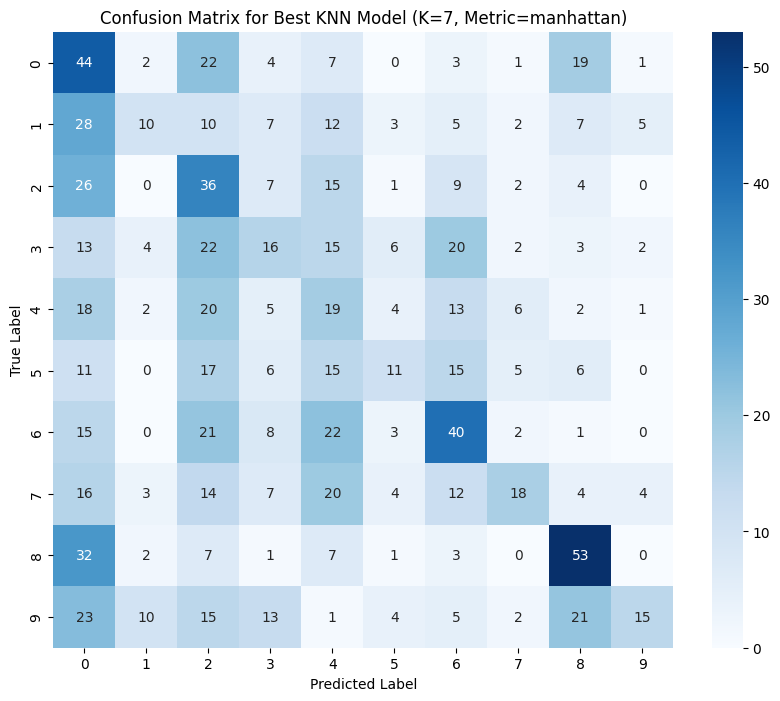


Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.43      0.27       103
           1       0.30      0.11      0.16        89
           2       0.20      0.36      0.25       100
           3       0.22      0.16      0.18       103
           4       0.14      0.21      0.17        90
           5       0.30      0.13      0.18        86
           6       0.32      0.36      0.34       112
           7       0.45      0.18      0.25       102
           8       0.44      0.50      0.47       106
           9       0.54      0.14      0.22       109

    accuracy                           0.26      1000
   macro avg       0.31      0.26      0.25      1000
weighted avg       0.31      0.26      0.25      1000



In [12]:
# Print Confusion Matrix for the best model
print(f"\n--- Evaluation for Best Model (K={best_k}, Metric={best_metric}) ---")
conf_matrix = confusion_matrix(y_test_subset, best_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix for Best KNN Model (K={best_k}, Metric={best_metric})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(y_test_subset, best_predictions)
print("\nClassification Report:")
print(class_report)


### 6. Visualizing the Impact of Different Distance Metrics on Accuracy Across Varying K Values

To better understand the experimental results, we will visualize how accuracy changes with different K values for each distance metric.

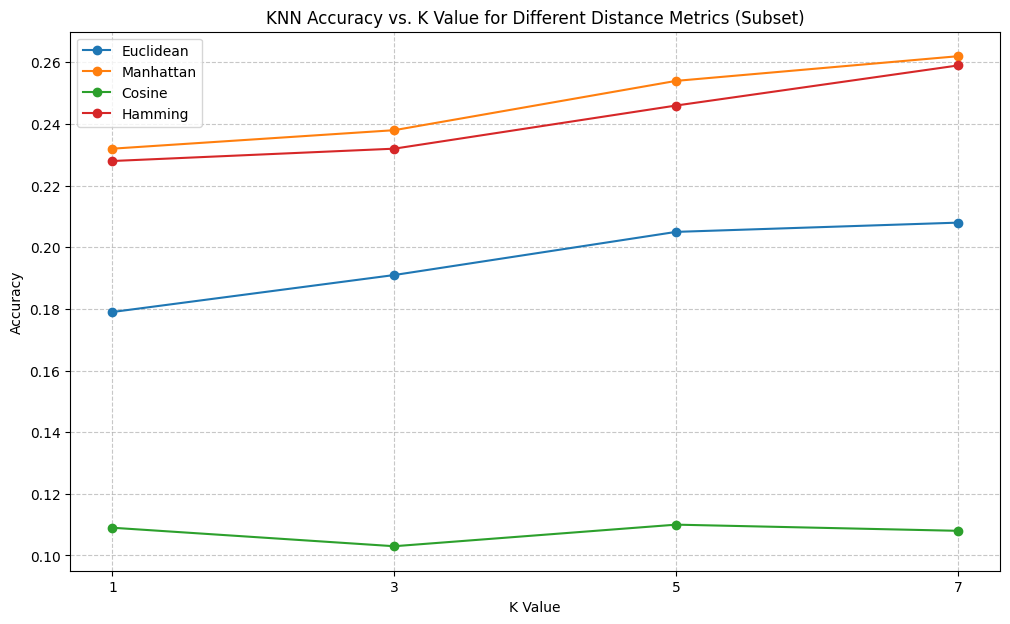

In [13]:
# Prepare data for plotting
plot_data = {metric: [] for metric in distance_metrics}
for (k, metric), accuracy in results.items():
    plot_data[metric].append(accuracy)

plt.figure(figsize=(12, 7))
for metric in distance_metrics:
    plt.plot(k_values, plot_data[metric], marker='o', label=metric.capitalize())

plt.title('KNN Accuracy vs. K Value for Different Distance Metrics (Subset)')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values) # Ensure K values are shown on x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
